In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("fsworld_data/fsworld_events_335-events_20260721_174635.parquet")
df.head()


,competition_id,event_id,competition_name,event_title,event_date,event_class,n_teams,rank,university,country,...,en_rank,en_pct,ef_pts,ef_rank,ef_pct,td_pts,td_rank,td_pct,penalty_pts,penalty_rank
0,1,409,Formula SAE® Michigan,Formula SAE® Michigan,2026-05,CV,111,1,UPV Valéncia,ES,...,33.0,72.0,72.5,33.0,72.0,72.5,33.0,72.0,113.1,4.0
1,1,409,Formula SAE® Michigan,Formula SAE® Michigan,2026-05,CV,111,2,Purdue West Lafayette,US,...,7.0,88.0,87.8,7.0,88.0,87.8,7.0,88.0,124.5,2.0
2,1,409,Formula SAE® Michigan,Formula SAE® Michigan,2026-05,CV,111,3,K-State Manhattan,US,...,12.0,86.0,86.0,12.0,86.0,86.0,12.0,86.0,112.5,5.0
3,1,409,Formula SAE® Michigan,Formula SAE® Michigan,2026-05,CV,111,4,U Conn Storrs,US,...,20.0,79.0,78.7,20.0,79.0,78.7,20.0,79.0,111.1,6.0
4,1,409,Formula SAE® Michigan,Formula SAE® Michigan,2026-05,CV,111,5,GTech Atlanta,US,...,25.0,77.0,77.0,25.0,77.0,77.0,25.0,77.0,91.6,15.0


In [26]:
print(df.shape[0])

13003


In [27]:
# Filter to the relevant regions, years and event classes
# Note: the exported parquet does not contain a dedicated event-country column,
# so we infer the country from the event title / competition name when possible.

df["event_class_clean"] = df["event_class"].astype(str).str.upper().str.strip()
df = df[df["event_class_clean"] != "CV"].copy()

df["event_year"] = pd.to_numeric(df["event_date"].astype(str).str.extract(r"^(\d{4})")[0], errors="coerce")
df = df[df["event_year"] >= 2023].copy()

country_keywords = {
    "france": "France",
    "switzerland": "Switzerland",
    "germany": "Germany",
    "czech": "Czech",
    "czech republic": "Czech",
    "italy": "Italy",
    "spain": "Spain",
}

def infer_event_country(text: str):
    text_low = str(text).lower()
    for keyword, country in country_keywords.items():
        if keyword in text_low:
            return country
    return None

country_text = df[["event_title", "competition_name"]].fillna("").astype(str).apply(
    lambda row: " ".join(row), axis=1
)
df["event_country"] = country_text.apply(infer_event_country)

allowed_countries = {"France", "Switzerland", "Germany", "Czech", "Italy", "Spain"}
df = df[df["event_country"].isin(allowed_countries)].copy()

# Make sure the numeric columns are usable
numeric_cols = [
    "total_pts", "ed_pts", "bp_pts", "cm_pts",
    "sp_pts", "ds_pts", "ac_pts", "da_pts", "ax_pts", "en_pts", "ef_pts", "td_pts"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Create flags for the full dynamic funnel
# This includes all dynamic disciplines, not only DV disciplines.
dynamic_cols = ["sp_pts", "ds_pts", "ac_pts", "da_pts", "ax_pts", "en_pts", "ef_pts", "td_pts"]
df["dynamic_any"] = df[dynamic_cols].gt(0).any(axis=1)
df["autocross_reached"] = df["ax_pts"] > 0
df["trackdrive_reached"] = df["td_pts"] > 0

df["has_static_score"] = df[["ed_pts", "bp_pts", "cm_pts"]].gt(0).any(axis=1)
df["only_static"] = df["has_static_score"] & ~df["dynamic_any"]
df["zero_total"] = df["total_pts"] == 0

# Event-level summary
# Group by event title to get a simple overview across events
# You can add event_date / competition_name if you want more granularity.
event_summary = (
    df.groupby(["event_title", "event_country"], as_index=False)
      .agg(
          teams=("rank", "count"),
          has_static_score_pct=("has_static_score", "mean"),
          dynamic_any_pct=("dynamic_any", "mean"),
          autocross_pct=("autocross_reached", "mean"),
          trackdrive_pct=("trackdrive_reached", "mean"),
          only_static_pct=("only_static", "mean"),
          zero_total_pct=("zero_total", "mean"),
      )
      .sort_values("only_static_pct", ascending=False)
)

event_summary.head()

,event_title,event_country,teams,has_static_score_pct,dynamic_any_pct,autocross_pct,trackdrive_pct,only_static_pct,zero_total_pct
2,Formula Student France,France,31,1.000000,0.870968,0.387097,0.322581,0.129032,0.000000
1,Formula Student Czech Republic,Czech,180,0.977778,0.850000,0.516667,0.505556,0.127778,0.022222
3,Formula Student Germany,Germany,332,0.987952,0.873494,0.560241,0.225904,0.117470,0.006024
0,Formula SAE® Italy,Italy,120,0.991667,0.941667,0.500000,0.466667,0.050000,0.008333
4,Formula Student Spain,Spain,107,1.000000,0.981308,0.327103,0.476636,0.018692,0.000000


In [28]:
overall = {
    "teams": len(df),
    "static_only_pct": df["only_static"].mean(),
    "dynamic_any_pct": df["dynamic_any"].mean(),
    "autocross_pct": df["autocross_reached"].mean(),
    "trackdrive_pct": df["trackdrive_reached"].mean(),
    "zero_total_pct": df["zero_total"].mean(),
}

overall

{'teams': 800,
 'static_only_pct': np.float64(0.0925),
 'dynamic_any_pct': np.float64(0.8975),
 'autocross_pct': np.float64(0.49875),
 'trackdrive_pct': np.float64(0.3725),
 'zero_total_pct': np.float64(0.00875)}

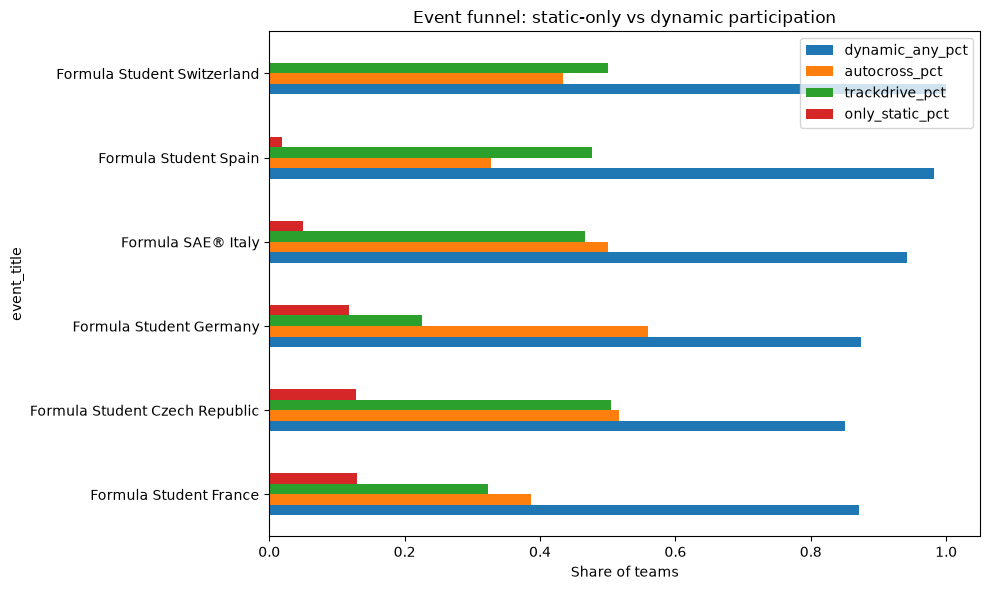

In [29]:
plot_df = event_summary[["event_title", "dynamic_any_pct", "autocross_pct", "trackdrive_pct", "only_static_pct"]].head(20)

plot_df.set_index("event_title").plot(kind="barh", figsize=(10, 6))
plt.title("Event funnel: static-only vs dynamic participation")
plt.xlabel("Share of teams")
plt.tight_layout()
plt.show()

In [30]:
# Percentage of teams getting 0 points for each discipline, per event and overall

# Discipline columns to inspect
zero_cols = [
    "ed_pts", "bp_pts", "cm_pts",
    "sp_pts", "ds_pts", "ac_pts", "da_pts", "ax_pts", "en_pts", "ef_pts", "td_pts"
]

# Map to friendly names
discipline_names = {
    "ed_pts": "Engineering Design",
    "bp_pts": "Business Plan",
    "cm_pts": "Cost & Manufacturing",
    "sp_pts": "Skidpad",
    "ds_pts": "DV Skidpad",
    "ac_pts": "Acceleration",
    "da_pts": "DV Acceleration",
    "ax_pts": "Autocross",
    "en_pts": "Endurance",
    "ef_pts": "Efficiency",
    "td_pts": "Trackdrive",
}

# Per-event zero-point percentages
per_event_zero = (
    df.groupby(["event_title", "event_country"], as_index=False)[zero_cols]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index()
)

# Flatten the multi-level result into a tidy format
per_event_zero_tidy = per_event_zero.melt(
    id_vars=["event_title", "event_country"],
    var_name="discipline",
    value_name="zero_pct"
)
per_event_zero_tidy["discipline"] = per_event_zero_tidy["discipline"].map(discipline_names)

per_event_zero_tidy.head()

# Overall zero-point percentages across all filtered rows
overall_zero = (
    df[zero_cols].eq(0).mean() * 100
)

overall_zero = pd.DataFrame({
    "discipline": list(overall_zero.index.map(discipline_names)),
    "zero_pct": overall_zero.values
}).sort_values("zero_pct", ascending=False)

overall_zero


,discipline,zero_pct
9,Efficiency,62.375
10,Trackdrive,62.375
6,DV Acceleration,62.375
8,Endurance,62.375
5,Acceleration,50.125
7,Autocross,50.125
4,DV Skidpad,14.000
2,Cost & Manufacturing,13.875
3,Skidpad,13.875
1,Business Plan,1.250
